In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

# decision tree for multioutput regression
from sklearn.datasets import make_regression
from sklearn.tree import DecisionTreeRegressor

# KNN for multioutput regression
from sklearn.datasets import make_regression
from sklearn.neighbors import KNeighborsRegressor

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from scipy.io import arff


In [4]:
data = arff.loadarff('/content/drive/MyDrive/Hasan sir/new_analysis/cocomo811.arff')
df = pd.DataFrame(data[0])
df.head()

,rely,data,cplx,time,stor,virt,turn,acap,aexp,pcap,vexp,lexp,modp,tool,sced,loc,actual
0,0.88,1.16,0.70,1.0,1.06,1.15,1.07,1.19,1.13,1.17,1.1,1.00,1.24,1.10,1.04,113.0,2040.0
1,0.88,1.16,0.85,1.0,1.06,1.00,1.07,1.00,0.91,1.00,0.9,0.95,1.10,1.00,1.00,293.0,1600.0
2,1.00,1.16,0.85,1.0,1.00,0.87,0.94,0.86,0.82,0.86,0.9,0.95,0.91,0.91,1.00,132.0,243.0
3,0.75,1.16,0.70,1.0,1.00,0.87,1.00,1.19,0.91,1.42,1.0,0.95,1.24,1.00,1.04,60.0,240.0
4,0.88,0.94,1.00,1.0,1.00,0.87,1.00,1.00,1.00,0.86,0.9,0.95,1.24,1.00,1.00,16.0,33.0


In [5]:
df.describe()

,rely,data,cplx,time,stor,virt,turn,acap,aexp,pcap,vexp,lexp,modp,tool,sced,loc,actual
count,63.000000,63.000000,63.000000,63.000000,63.00000,63.000000,63.000000,63.000000,63.000000,63.00000,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000
mean,1.036349,1.003968,1.091429,1.113810,1.14381,1.008413,0.971746,0.905238,0.948571,0.93746,1.005238,1.001429,1.004127,1.016984,1.048889,77.209841,683.320635
std,0.193477,0.073431,0.202563,0.161639,0.17942,0.120593,0.080973,0.151507,0.119243,0.16651,0.093375,0.051988,0.130935,0.085735,0.075586,168.509374,1821.582348
min,0.750000,0.940000,0.700000,1.000000,1.00000,0.870000,0.870000,0.710000,0.820000,0.70000,0.900000,0.950000,0.820000,0.830000,1.000000,1.980000,5.900000
25%,0.880000,0.940000,1.000000,1.000000,1.00000,0.870000,0.870000,0.860000,0.820000,0.86000,0.900000,0.950000,0.910000,1.000000,1.000000,8.650000,40.500000
50%,1.000000,1.000000,1.070000,1.060000,1.06000,1.000000,1.000000,0.860000,1.000000,0.86000,1.000000,1.000000,1.000000,1.000000,1.000000,25.000000,98.000000
75%,1.150000,1.040000,1.300000,1.110000,1.21000,1.150000,1.000000,1.000000,1.000000,1.00000,1.100000,1.000000,1.100000,1.100000,1.080000,60.000000,438.000000
max,1.400000,1.160000,1.650000,1.660000,1.56000,1.300000,1.150000,1.460000,1.290000,1.42000,1.210000,1.140000,1.240000,1.240000,1.230000,1150.000000,11400.000000


<Axes: title={'center': 'Pearson Correlation of Features'}>

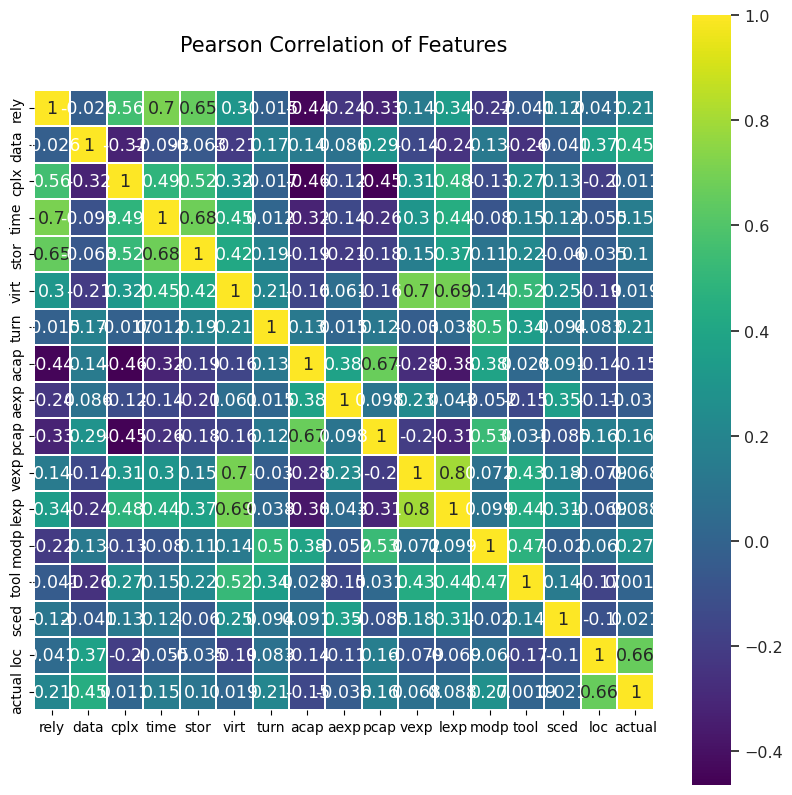

In [6]:
colormap = plt.cm.viridis
plt.figure(figsize=(10,10))
plt.title('Pearson Correlation of Features', y=1.05, size=15)
sns.set(font_scale=1.05)
sns.heatmap(df.astype(float).corr(),linewidths=0.1,vmax=1.0, square=True,cmap=colormap, linecolor='white', annot=True)

In [7]:
# map features to their absolute correlation values
corr = df.corr().abs()

# set equality (self correlation) as zero
corr[corr == 1] = 0

# of each feature, find the max correlation
# and sort the resulting array in ascending order
corr_cols = corr.max().sort_values(ascending=False)

# display the highly correlated fe
#corr_cols

# display the highly correlated features
display(corr_cols[corr_cols > 0.6])

lexp      0.796514
vexp      0.796514
rely      0.702636
time      0.702636
virt      0.697887
stor      0.677825
pcap      0.667691
acap      0.667691
loc       0.657223
actual    0.657223
dtype: float64

In [8]:
#features = [ 'TeamExp', 'ManagerExp', 'YearEnd', 'Length', 'Transactions', 'Entities','PointsNonAdjust', 'Adjustment', 'PointsAjust']

max_corr_features = ['lexp', 'vexp', 'rely','time','virt', 'stor','pcap','acap','loc','actual']

X = df[max_corr_features]
y = df['actual']

In [9]:
# Splitting the dataset into the Training set and Test set
X_Train, X_Test, Y_Train, Y_Test = train_test_split(X, y, test_size=0.30, random_state=30)

# ***KNeighborsRegressor***

In [10]:
#KNeighborsRegressor
neigh = KNeighborsRegressor(n_neighbors=9, weights='uniform')
neigh.fit(X_Train, Y_Train)
predict_knn = neigh.predict(X_Test)
#print("Root mean square: ", np.sqrt(mean_squared_error(Y_Test, predict_knn)))
#print("Mean Absolute error", mean_absolute_error(Y_Test, predict_knn))

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [12]:
# Function to calculate Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [13]:
# Calculate evaluation metrics
mae = mean_absolute_error(Y_Test, predict_knn)
mse = mean_squared_error(Y_Test, predict_knn)
rmse = np.sqrt(mse)
r_squared = r2_score(Y_Test, predict_knn)
mape = mean_absolute_percentage_error(Y_Test, predict_knn)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r_squared:.2f}")
print(f"mape: {mape:.2f}")

Mean Absolute Error (MAE): 380.40
Mean Squared Error (MSE): 842748.51
Root Mean Squared Error (RMSE): 918.01
R-squared (R²): 0.59
mape: 29.38


In [14]:
import matplotlib.pyplot as plot
import pandas

In [15]:
# Splitting the dataset into the Training set and Test set
X_Train, X_Test, Y_Train, Y_Test = train_test_split(X, y, test_size=0.30, random_state=30)

In [16]:
Y_Train.shape

(44,)

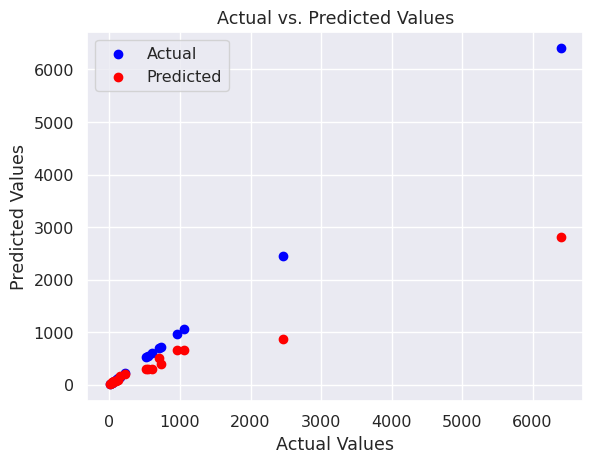

In [17]:
import matplotlib.pyplot as plt

# Sample actual and predicted values
actual_values = Y_Test                 #[0:50]
predicted_values = predict_knn             #[0:50]

# Create scatter plot for actual values
plt.scatter(actual_values, actual_values, c='blue', label='Actual')
# Create scatter plot for predicted values
plt.scatter(actual_values, predicted_values, c='red', label='Predicted')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.grid(True)

plt.show()

In [18]:
import seaborn as sns

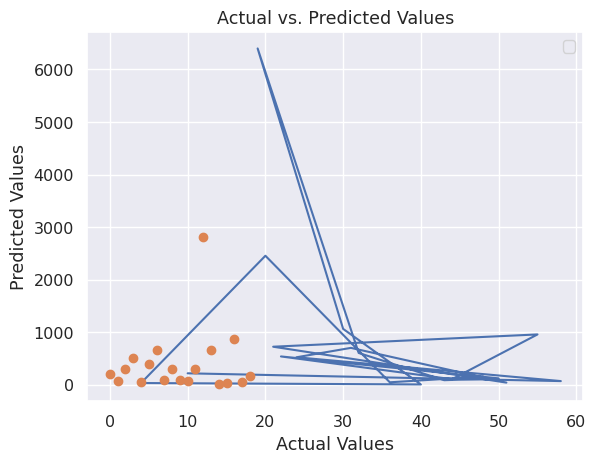

In [19]:
import matplotlib.pyplot as plt
plt.plot(Y_Test)
plt.plot(predict_knn, 'o')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.grid(True)

plt.show()

# ***LinearRegression***

In [20]:
regressor = LinearRegression()
regressor.fit(X_Train, Y_Train)
predict_LR = regressor.predict(X_Test)
#print("Root mean square: ", np.sqrt(mean_squared_error(Y_Test, predict_LR)))
#print("Mean Absolute error", mean_absolute_error(Y_Test, predict_LR))

In [21]:
# Function to calculate Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [22]:
# Calculate evaluation metrics
mae = mean_absolute_error(Y_Test, predict_LR)
mse = mean_squared_error(Y_Test, predict_LR)
rmse = np.sqrt(mse)
r_squared = r2_score(Y_Test, predict_LR)
mape = mean_absolute_percentage_error(Y_Test, predict_LR)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r_squared:.2f}")
print(f"mape: {mape:.2f}")

Mean Absolute Error (MAE): 0.00
Mean Squared Error (MSE): 0.00
Root Mean Squared Error (RMSE): 0.00
R-squared (R²): 1.00
mape: 0.00


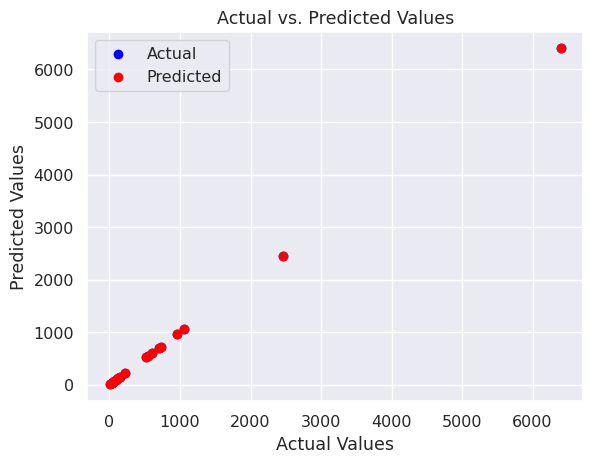

In [23]:
import matplotlib.pyplot as plt

# Sample actual and predicted values
actual_values = Y_Test                 #[0:50]
predicted_values = predict_LR             #[0:50]

# Create scatter plot for actual values
plt.scatter(actual_values, actual_values, c='blue', label='Actual')
# Create scatter plot for predicted values
plt.scatter(actual_values, predicted_values, c='red', label='Predicted')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.grid(True)

plt.show()

# ***RandomForestRegressor***

In [24]:
regressor = RandomForestRegressor(n_estimators=100,max_features=5)
regressor.fit(X_Train, Y_Train)
predict_RF = regressor.predict(X_Test)
print("Root mean square: ", np.sqrt(mean_squared_error(Y_Test, predict_RF)))
print("Mean Absolute error", mean_absolute_error(Y_Test, predict_RF))

Root mean square:  536.1535548626365
Mean Absolute error 263.9042631578948


In [25]:
# Function to calculate Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [26]:
# Calculate evaluation metrics
mae = mean_absolute_error(Y_Test, predict_RF)
mse = mean_squared_error(Y_Test, predict_RF)
rmse = np.sqrt(mse)
r_squared = r2_score(Y_Test, predict_RF)
mape = mean_absolute_percentage_error(Y_Test, predict_RF)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r_squared:.2f}")
print(f"mape: {mape:.2f}")

Mean Absolute Error (MAE): 263.90
Mean Squared Error (MSE): 287460.63
Root Mean Squared Error (RMSE): 536.15
R-squared (R²): 0.86
mape: 49.57


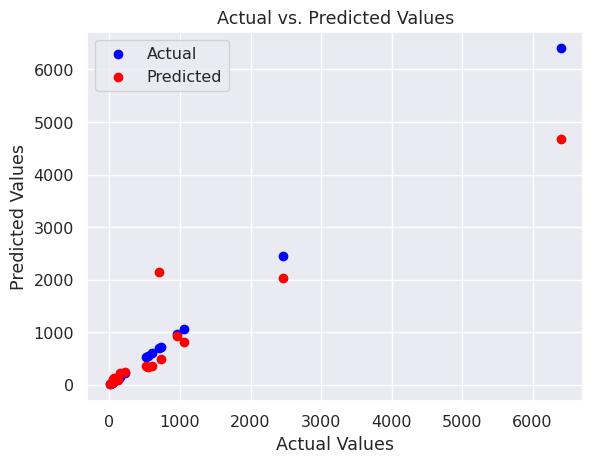

In [27]:
import matplotlib.pyplot as plt

# Sample actual and predicted values
actual_values = Y_Test                 #[0:50]
predicted_values = predict_RF             #[0:50]

# Create scatter plot for actual values
plt.scatter(actual_values, actual_values, c='blue', label='Actual')
# Create scatter plot for predicted values
plt.scatter(actual_values, predicted_values, c='red', label='Predicted')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.grid(True)

plt.show()

In [28]:
# Function to calculate Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [29]:
# Calculate evaluation metrics
mae = mean_absolute_error(Y_Test, predict_RF)
mse = mean_squared_error(Y_Test, predict_RF)
rmse = np.sqrt(mse)
r_squared = r2_score(Y_Test, predict_RF)
mape = mean_absolute_percentage_error(Y_Test, predict_RF)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r_squared:.2f}")
print(f"mape: {mape:.2f}")

Mean Absolute Error (MAE): 263.90
Mean Squared Error (MSE): 287460.63
Root Mean Squared Error (RMSE): 536.15
R-squared (R²): 0.86
mape: 49.57


# ***SVM***

In [30]:
parameters = {'kernel':('linear', 'rbf'), 'C':[1,2,3,4,5,6,7,8,9,10, 100, 500], 'gamma':('auto', 'scale')}

svr = SVR()
LinearSVC = GridSearchCV(svr, parameters, cv=3)
LinearSVC.fit(X_Train, Y_Train)
predict_SVM = LinearSVC.predict(X_Test)
print("Root mean square: ", np.sqrt(mean_squared_error(Y_Test, predict_SVM)))
print("Mean Absolute error", mean_absolute_error(Y_Test, predict_SVM))

Root mean square:  0.09099522963469353
Mean Absolute error 0.08848020558525745


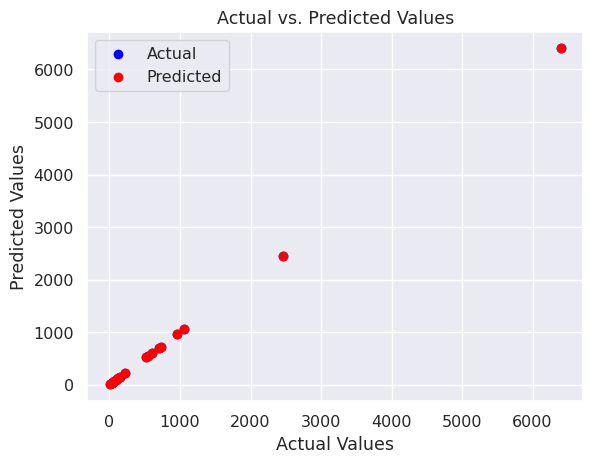

In [31]:
import matplotlib.pyplot as plt

# Sample actual and predicted values
actual_values = Y_Test                 #[0:50]
predicted_values = predict_SVM             #[0:50]

# Create scatter plot for actual values
plt.scatter(actual_values, actual_values, c='blue', label='Actual')
# Create scatter plot for predicted values
plt.scatter(actual_values, predicted_values, c='red', label='Predicted')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.grid(True)

plt.show()

In [32]:
# Function to calculate Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [33]:
# Calculate evaluation metrics
mae = mean_absolute_error(Y_Test, predict_SVM)
mse = mean_squared_error(Y_Test, predict_SVM)
rmse = np.sqrt(mse)
r_squared = r2_score(Y_Test, predict_SVM)
mape = mean_absolute_percentage_error(Y_Test, predict_SVM)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r_squared:.2f}")
print(f"mape: {mape:.2f}")

Mean Absolute Error (MAE): 0.09
Mean Squared Error (MSE): 0.01
Root Mean Squared Error (RMSE): 0.09
R-squared (R²): 1.00
mape: 0.16


# ***lasso***

In [34]:
from sklearn import linear_model

In [35]:
#clf = linear_model.Lasso(alpha=0.1)

In [36]:
#clf.fit(X_train, y_train)

In [37]:
clf = linear_model.Lasso(alpha=0.1)
clf.fit(X_Train, Y_Train)
print(clf.coef_)
print(clf.intercept_)
# make a prediction
predict_LS = clf.predict(X_Test)
# summarize prediction
print("Root mean square: ", np.sqrt(mean_squared_error(Y_Test, predict_LS)))
print("Mean Absolute error", mean_absolute_error(Y_Test, predict_LS))

[-0.00000000e+00 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00
 -0.00000000e+00 -0.00000000e+00  0.00000000e+00  0.00000000e+00
 -3.41691959e-05  1.00000217e+00]
0.001135027932491539
Root mean square:  0.0028971903765392173
Mean Absolute error 0.0017045771156530538


In [38]:
# Function to calculate Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [39]:
# Calculate evaluation metrics
mae = mean_absolute_error(Y_Test, predict_LS)
mse = mean_squared_error(Y_Test, predict_LS)
rmse = np.sqrt(mse)
r_squared = r2_score(Y_Test, predict_LS)
mape = mean_absolute_percentage_error(Y_Test, predict_LS)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r_squared:.2f}")
print(f"mape: {mape:.2f}")

Mean Absolute Error (MAE): 0.00
Mean Squared Error (MSE): 0.00
Root Mean Squared Error (RMSE): 0.00
R-squared (R²): 1.00
mape: 0.00


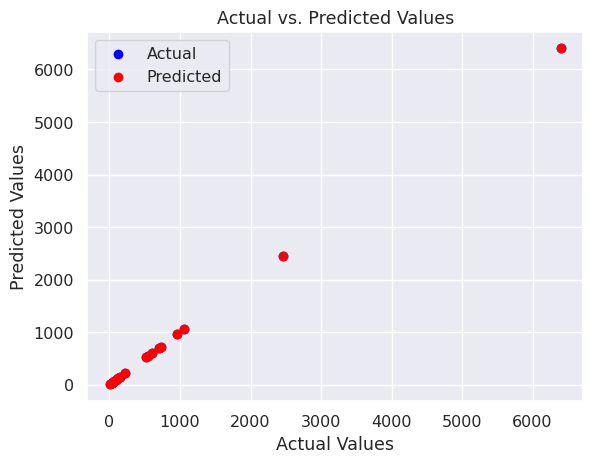

In [40]:
import matplotlib.pyplot as plt

# Sample actual and predicted values
actual_values = Y_Test                 #[0:50]
predicted_values = predict_LS             #[0:50]

# Create scatter plot for actual values
plt.scatter(actual_values, actual_values, c='blue', label='Actual')
# Create scatter plot for predicted values
plt.scatter(actual_values, predicted_values, c='red', label='Predicted')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.grid(True)

plt.show()